## ML-Oriented EDA

In [1]:
import os
import sys

sys.path.append(os.path.abspath(".."))

In [8]:
from src.data_utils import load_raw
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=load_raw("application_train.csv")

### 1. Target Imbalance Analysis

In [5]:
target_dist=df['TARGET'].value_counts(normalize=True)
target_dist

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

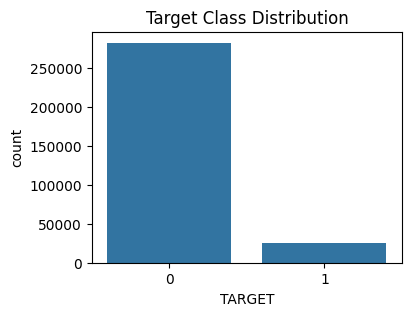

In [9]:
plt.figure(figsize=(4,3))
sns.countplot(x=df['TARGET'], data=df)
plt.title('Target Class Distribution')
plt.show()

Approximately ~8% of applicants are default.

This confirms strong class imbalance.

Implication:
- Accuracy is misleading
- ROC-AUC or PR-AUC should be preferred
- Stratified split is required

### 2. Missing Value Analysis

In [10]:
missing_ratio=df.isna().mean().sort_values(ascending=False)
missing_ratio.head(20)

COMMONAREA_AVG              0.698723
COMMONAREA_MODE             0.698723
COMMONAREA_MEDI             0.698723
NONLIVINGAPARTMENTS_MEDI    0.694330
NONLIVINGAPARTMENTS_MODE    0.694330
NONLIVINGAPARTMENTS_AVG     0.694330
FONDKAPREMONT_MODE          0.683862
LIVINGAPARTMENTS_AVG        0.683550
LIVINGAPARTMENTS_MEDI       0.683550
LIVINGAPARTMENTS_MODE       0.683550
FLOORSMIN_MODE              0.678486
FLOORSMIN_AVG               0.678486
FLOORSMIN_MEDI              0.678486
YEARS_BUILD_AVG             0.664978
YEARS_BUILD_MODE            0.664978
YEARS_BUILD_MEDI            0.664978
OWN_CAR_AGE                 0.659908
LANDAREA_MEDI               0.593767
LANDAREA_AVG                0.593767
LANDAREA_MODE               0.593767
dtype: float64

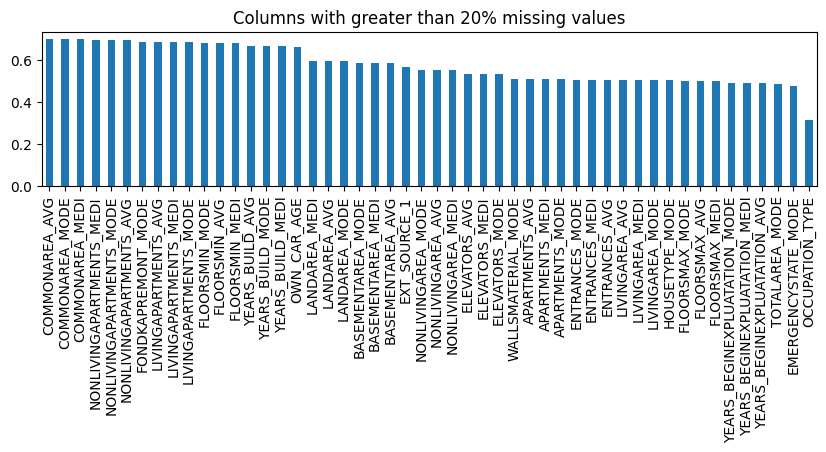

In [19]:
missing_ratio[missing_ratio>0.2].plot(kind='bar', figsize=(10,2))
plt.title("Columns with greater than 20% missing values")
plt.show()

Many features contain significant missing values.

Potential strategies:
- Drop column with extreame high missing (>60%)
- Impute numerical features (median)
- Impute categorical feature (mode or "Missing")
- Create missing indication flag

Some missing values may represent:
- No credit history
- No previous loans

Missings may carry predictive signals.

### 3. High-Cardinality Categorical Features

In [11]:
cat_cols=df.select_dtypes(include=object).columns
cardinality=df[cat_cols].nunique().sort_values(ascending=False)
cardinality.head(20)

ORGANIZATION_TYPE             58
OCCUPATION_TYPE               18
NAME_INCOME_TYPE               8
NAME_TYPE_SUITE                7
WALLSMATERIAL_MODE             7
WEEKDAY_APPR_PROCESS_START     7
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
NAME_EDUCATION_TYPE            5
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
CODE_GENDER                    3
FLAG_OWN_CAR                   2
NAME_CONTRACT_TYPE             2
FLAG_OWN_REALTY                2
EMERGENCYSTATE_MODE            2
dtype: int64

Features with large numbers of categories may:
- Increase dimentionality
- Increase overfitting risk
- Lead to sparse matrices

Possible handling strategies:
- Frequency encoding
- Group rare categories
- Target encoding with cross-validation

### 4. Outlier Detection (Numerical Features)

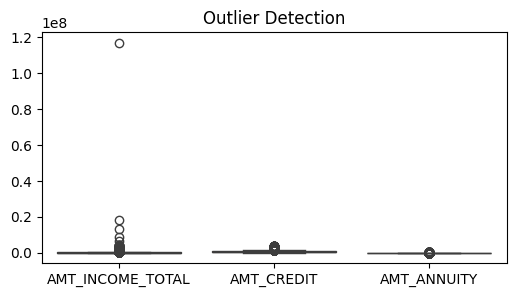

In [47]:
plt.figure(figsize=(6,3))
sns.boxplot(data=df[['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']])
plt.title('Outlier Detection')
plt.show()

In [12]:
num_col=df.select_dtypes(include='number').columns
bin_col=[col for col in num_col if df[col].nunique()<=2]

cnt_col=[col for col in num_col if col not in bin_col]

df[cnt_col].skew().sort_values(ascending=False).head(20)

AMT_INCOME_TOTAL              391.559654
AMT_REQ_CREDIT_BUREAU_QRT     134.365776
AMT_REQ_CREDIT_BUREAU_DAY      27.043505
NONLIVINGAPARTMENTS_MODE       16.251819
NONLIVINGAPARTMENTS_MEDI       15.671995
NONLIVINGAPARTMENTS_AVG        15.541185
AMT_REQ_CREDIT_BUREAU_HOUR     14.534062
OBS_30_CNT_SOCIAL_CIRCLE       12.139598
OBS_60_CNT_SOCIAL_CIRCLE       12.070829
AMT_REQ_CREDIT_BUREAU_WEEK      9.293573
AMT_REQ_CREDIT_BUREAU_MON       7.804848
NONLIVINGAREA_AVG               6.559012
NONLIVINGAREA_MODE              6.522451
NONLIVINGAREA_MEDI              6.508831
COMMONAREA_MODE                 5.620589
COMMONAREA_AVG                  5.457305
COMMONAREA_MEDI                 5.419238
DEF_60_CNT_SOCIAL_CIRCLE        5.277878
DEF_30_CNT_SOCIAL_CIRCLE        5.183518
LANDAREA_AVG                    4.458677
dtype: float64

Several financial and count-based variables shows extreame positive skewness:
- AMT_INCOME_TOTAL    (skew = 391)
- AMT_REQ_CREDIT_BUREAU_QRT    (skew=134)

Potential strategies:
- Log transformation
- Windorization
- Clipping at 99 percentile
- Apply log transformation

Outlier may represent:
- Data entry error
- High-income clients (legitimate)

Careful treatment is required.

### 5. Correlation Analysis

Examine correlations between numeric features to identify potential multicollinearity and redundancy.

Highly correlated features (e.g. *_AVG, *_MEDI, *_MODE) may require feature selection during preprocessing.

In [13]:
corr=df[cnt_col].corr()
corr

,SK_ID_CURR,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
SK_ID_CURR,1.000000,-0.001129,-0.001820,-0.000343,-0.000433,-0.000232,0.000849,-0.001500,0.001366,-0.000973,...,-0.000082,-0.001423,0.001187,-0.000858,-0.002672,-0.002193,0.002099,0.000485,0.001025,0.004659
CNT_CHILDREN,-0.001129,1.000000,0.012882,0.002145,0.021374,-0.001827,-0.025573,0.330938,-0.239818,0.183395,...,-0.001262,0.015232,-0.001861,-0.005865,-0.000410,-0.000366,-0.002436,-0.010808,-0.007836,-0.041550
AMT_INCOME_TOTAL,-0.001820,0.012882,1.000000,0.156870,0.191657,0.159610,0.074796,0.027261,-0.064223,0.027805,...,-0.013244,-0.013015,-0.013135,-0.018585,0.000709,0.002944,0.002387,0.024700,0.004859,0.011690
AMT_CREDIT,-0.000343,0.002145,0.156870,1.000000,0.770138,0.986968,0.099738,-0.055436,-0.066838,0.009621,...,-0.021229,0.000239,-0.023767,-0.073701,-0.003906,0.004238,-0.001275,0.054451,0.015925,-0.048448
AMT_ANNUITY,-0.000433,0.021374,0.191657,0.770138,1.000000,0.775109,0.118429,0.009445,-0.104332,0.038514,...,-0.022833,-0.011731,-0.024001,-0.063747,0.003861,0.002185,0.013881,0.039148,0.010124,-0.011320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,-0.002193,-0.000366,0.002944,0.004238,0.002185,0.004677,0.001399,0.002255,0.000472,-0.000508,...,-0.001272,-0.002542,-0.001822,0.002337,0.230374,1.000000,0.217412,-0.005258,-0.004416,-0.003355
AMT_REQ_CREDIT_BUREAU_WEEK,0.002099,-0.002436,0.002387,-0.001275,0.013881,-0.001007,-0.002149,-0.001336,0.003072,-0.001069,...,-0.002167,0.000197,-0.002536,-0.003495,0.004706,0.217412,1.000000,-0.014096,-0.015115,0.018917
AMT_REQ_CREDIT_BUREAU_MON,0.000485,-0.010808,0.024700,0.054451,0.039148,0.056422,0.078607,0.001372,-0.034457,-0.011353,...,0.000331,0.001639,-0.001462,-0.041244,-0.000018,-0.005258,-0.014096,1.000000,-0.007789,-0.004975
AMT_REQ_CREDIT_BUREAU_QRT,0.001025,-0.007836,0.004859,0.015925,0.010124,0.016432,-0.001279,-0.011799,0.015345,-0.001308,...,-0.001302,0.003932,-0.000291,-0.001451,-0.002716,-0.004416,-0.015115,-0.007789,1.000000,0.076208


### 6. Multi-Table Quick Checks

In [49]:
bureau=load_raw("bureau.csv")
bureau.shape

(1716428, 17)

In [51]:
bureau.isna().mean().sort_values(ascending=False).head(6)

AMT_ANNUITY               0.714735
AMT_CREDIT_MAX_OVERDUE    0.655133
DAYS_ENDDATE_FACT         0.369170
AMT_CREDIT_SUM_LIMIT      0.344774
AMT_CREDIT_SUM_DEBT       0.150119
DAYS_CREDIT_ENDDATE       0.061496
dtype: float64

### Modeling Implication Summary

Based on EDA:
- Dataset is highly imbalanced
- Missing values are significant and informative
- Several categorical features have high cardinality
- Numerical features contain heavy skew and outliers

These finding will influence:
- Feature engineering strategy
- Encoding decisions
- Imputation strategy
- Model selection
- Evaluation metric choice

### Train-Test Leakage Awareness

All preprocessing steps (imputation, encoding, scaling, feature engineering) will be done only for training data and then applied to validation/test sets to prevent leakage.